# Ratio-CATE Learner Benchmark

Evaluation of meta-learners for ratio-based CATE estimation:
$$\tau(x) = \frac{E[Y|W=1,X]}{E[Y|W=0,X]}$$

## Setup

In [77]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import ALL_DATASETS
from learner import ALL_LEARNER
from benchmark import run_benchmark


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

In [78]:
# Datasets to evaluate
DATASETS = ALL_DATASETS
# Learners to evaluate (calibrated variants are evaluated automatically in the loop)
LEARNER = list(ALL_LEARNER.keys())

# Number of runs per combination
N_RUNS = 50

# Base seed (each run uses BASE_SEED + run_idx)
BASE_SEED = 42

In [79]:
print(f"Datasets: {DATASETS}")
print(f"Learners: {LEARNER}")
print(f"Runs per combination: {N_RUNS}")


Datasets: ['hillstrom_visit', 'hillstrom_conversion', 'criteo', 'megafon', 'x5_retail', 'lenta', 'rhc', 'cattaneo', 'nhefs', 'jtpa', 'twins']
Learners: ['s', 't', 'q', 'q_simple', 'drt_log', 'drs_log', 'drq_log', 'drt_direct', 'drs_direct', 'drq_direct', 'drq_simple_log', 'drq_simple_direct', 'x', 'x_log', 'r', 'r_log', 'dr_diff']
Runs per combination: 50


## Run Benchmark

In [80]:
df_results = run_benchmark(
    datasets=DATASETS,
    learners=LEARNER,
    n_runs=N_RUNS,
    base_seed=BASE_SEED,
    results_csv='benchmark_results.csv',
)
df_results.head(10)


Loaded 8750 existing results from benchmark_results.csv
Skipping 8750 already-completed combinations


Datasets: 100%|██████████| 11/11 [00:28<00:00,  2.61s/it]


,Unnamed: 0,dataset,learner,run,seed,qini_ratio,qini_difference,cal_error_ratio,cal_error_difference
0,0.0,hillstrom_visit,s,0,42,0.530647,0.005089,1.198818,0.016934
1,1.0,hillstrom_visit,t,0,42,0.593834,0.002908,1.416907,0.036500
2,2.0,hillstrom_visit,q,0,42,0.094083,0.000404,1.486788,0.044412
3,3.0,hillstrom_visit,q_simple,0,42,0.109698,0.001561,1.468316,0.046376
4,4.0,hillstrom_visit,drt_log,0,42,0.301896,-0.000015,1.854985,0.116860
5,5.0,hillstrom_visit,drs_log,0,42,0.312840,0.001879,1.641179,0.094149
6,6.0,hillstrom_visit,drq_log,0,42,0.111925,0.000405,1.791256,0.121634
7,7.0,hillstrom_visit,drt_direct,0,42,0.693303,0.004002,2.494225,0.233792
8,8.0,hillstrom_visit,drs_direct,0,42,0.482795,0.004032,2.139831,0.183233
9,9.0,hillstrom_visit,drq_direct,0,42,0.602461,0.004415,2.494769,0.234864


## Export Results

In [81]:
# Save raw results
df_results.to_csv('benchmark_results.csv', index=False)

print("Results saved to benchmark_results.csv")

Results saved to benchmark_results.csv


## Visualizations

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import (
    RCT_DATASETS, OBS_DATASETS, SEMI_SYNTHETIC_DATASETS, CONVERSION_RATES,
)
from visualization import plot_metric_panels
from tables import make_metric_table

# --- Dataset groups ---
RCT_ALL = RCT_DATASETS + SEMI_SYNTHETIC_DATASETS

# Conversion rate per RCT dataset (used for the regime-split plots)
RCT_CONV = {d: CONVERSION_RATES[d] for d in RCT_ALL}
RCT_LOW_CONV  = [d for d, c in RCT_CONV.items() if c <  0.1]
RCT_HIGH_CONV = [d for d, c in RCT_CONV.items() if c >= 0.1]

DS_LABEL = {
    'hillstrom_conversion': 'H(Conv)', 'twins': 'Twins',
    'criteo': 'Criteo', 'lenta': 'Lenta',
    'hillstrom_visit': 'H(Vis)', 'megafon': 'MegaFon', 'x5_retail': 'X5',
}

# --- Learner display labels ---
PLOT_LEARNERS = {
    's':                  'S',
    't':                  'T',
    'q':                  'Q',
    'q_simple':           'Q-Simple',
    'drq_direct':         'DR-Q',
    'drq_log':            'DR-Q log',
    'drq_simple_direct':  'DR-Q-Simple',
    'drq_simple_log':     'DR-Q-Simple log',
    'drt_direct':         'DR-T',
    'drt_log':            'DR-T log',
    'drs_direct':         'DR-S',
    'drs_log':            'DR-S log',
    'x':                  'X',
    'x_log':              'X log',
    'r':                  'R',
    'r_log':              'R log',
    'dr_diff':            'DR',
}

plt.rcParams.update({'font.size': 11, 'figure.dpi': 150})

print(f"df_results rows: {len(df_results)}")
print(f"learners present: {sorted(df_results['learner'].unique())}")
print(f"datasets present: {sorted(df_results['dataset'].unique())}")


df_results rows: 8750
learners present: ['dr_diff', 'drq_direct', 'drq_log', 'drq_simple_direct', 'drq_simple_log', 'drs_direct', 'drs_log', 'drt_direct', 'drt_log', 'q', 'q_simple', 'r', 'r_log', 's', 't', 'x', 'x_log']
datasets present: ['cattaneo', 'criteo', 'hillstrom_conversion', 'hillstrom_visit', 'jtpa', 'lenta', 'megafon', 'nhefs', 'rhc', 'twins', 'x5_retail']


### Qini ratio (ratio CATE)

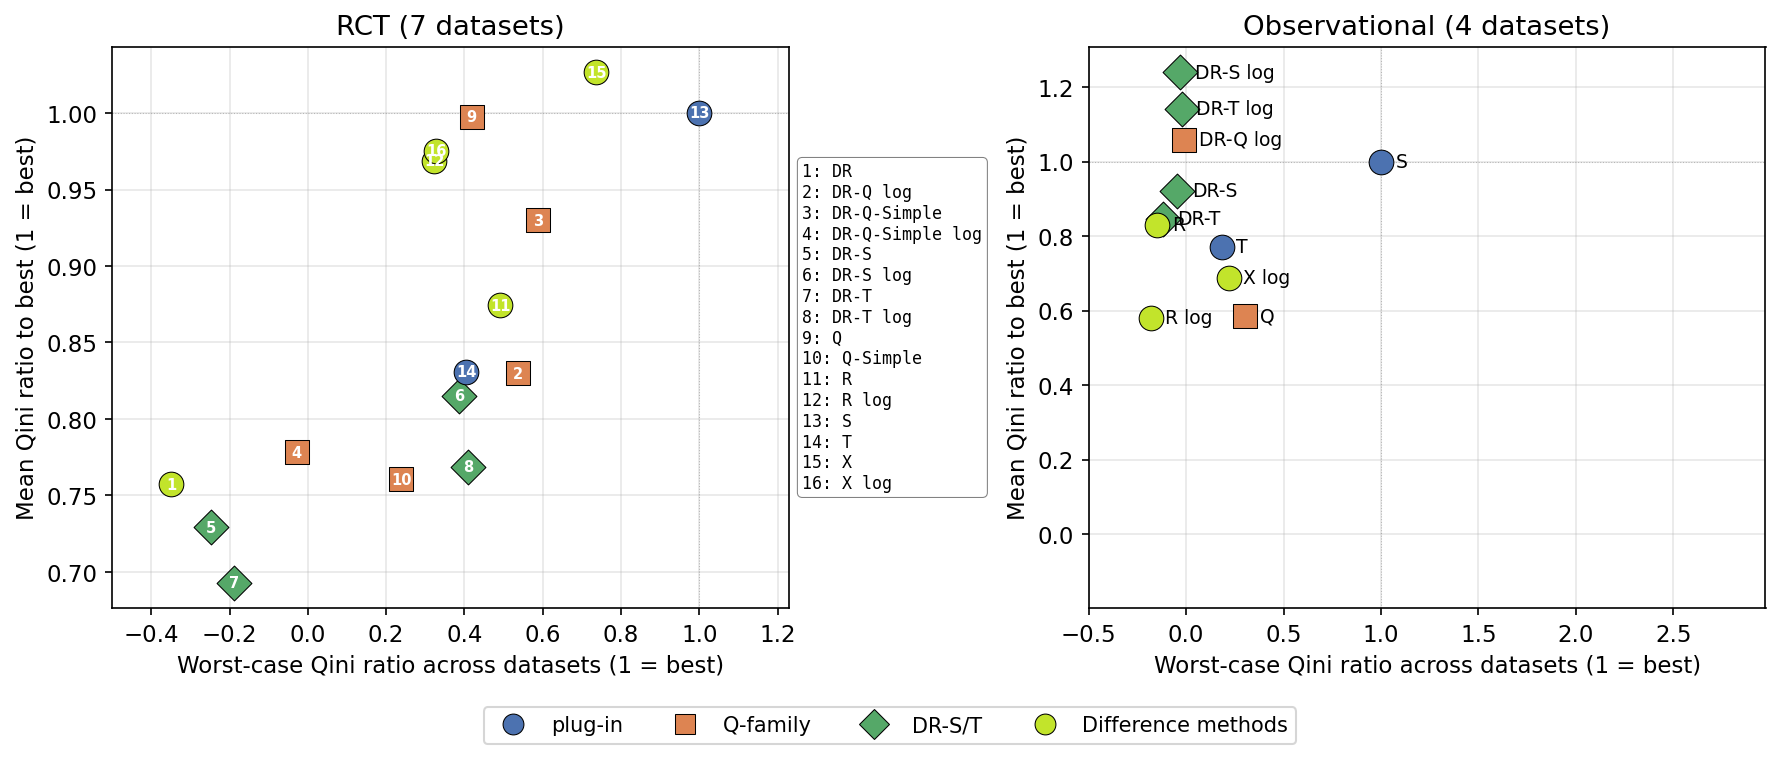

                  mean  worst
label                        
DR               0.757 -0.349
DR-Q             0.710 -3.571
DR-Q log         0.830  0.537
DR-Q-Simple      0.930  0.589
DR-Q-Simple log  0.778 -0.029
DR-S             0.729 -0.248
DR-S log         0.815  0.386
DR-T             0.693 -0.189
DR-T log         0.769  0.409
Q                0.998  0.418
Q-Simple         0.760  0.239
R                0.874  0.491
R log            0.969  0.323
S                1.000  1.000
T                0.831  0.405
X                1.027  0.736
X log            0.976  0.328

                  mean   worst
label                         
DR               0.382  -7.377
DR-Q             0.527  -9.438
DR-Q log         1.058  -0.010
DR-Q-Simple      0.000     NaN
DR-Q-Simple log  0.000     NaN
DR-S             0.921  -0.044
DR-S log         1.240  -0.029
DR-T             0.846  -0.120
DR-T log         1.141  -0.023
Q                0.586   0.304
Q-Simple         0.000     NaN
R                0.831  -0

In [101]:
# Figure 1 — Qini ratio (ratio CATE) for RCT vs Observational
fig, summaries = plot_metric_panels(
    df_results,
    metric='qini_ratio',
    panels=[
        (f'RCT ({len(RCT_ALL)} datasets)', RCT_ALL),
        (f'Observational ({len(OBS_DATASETS)} datasets)', OBS_DATASETS),
    ],
    plot_learners=PLOT_LEARNERS,
    savepath='fig_qini_ratio.png',
)
for s in summaries:
    print(s.round(3))
    print()


### Qini difference (difference CATE)

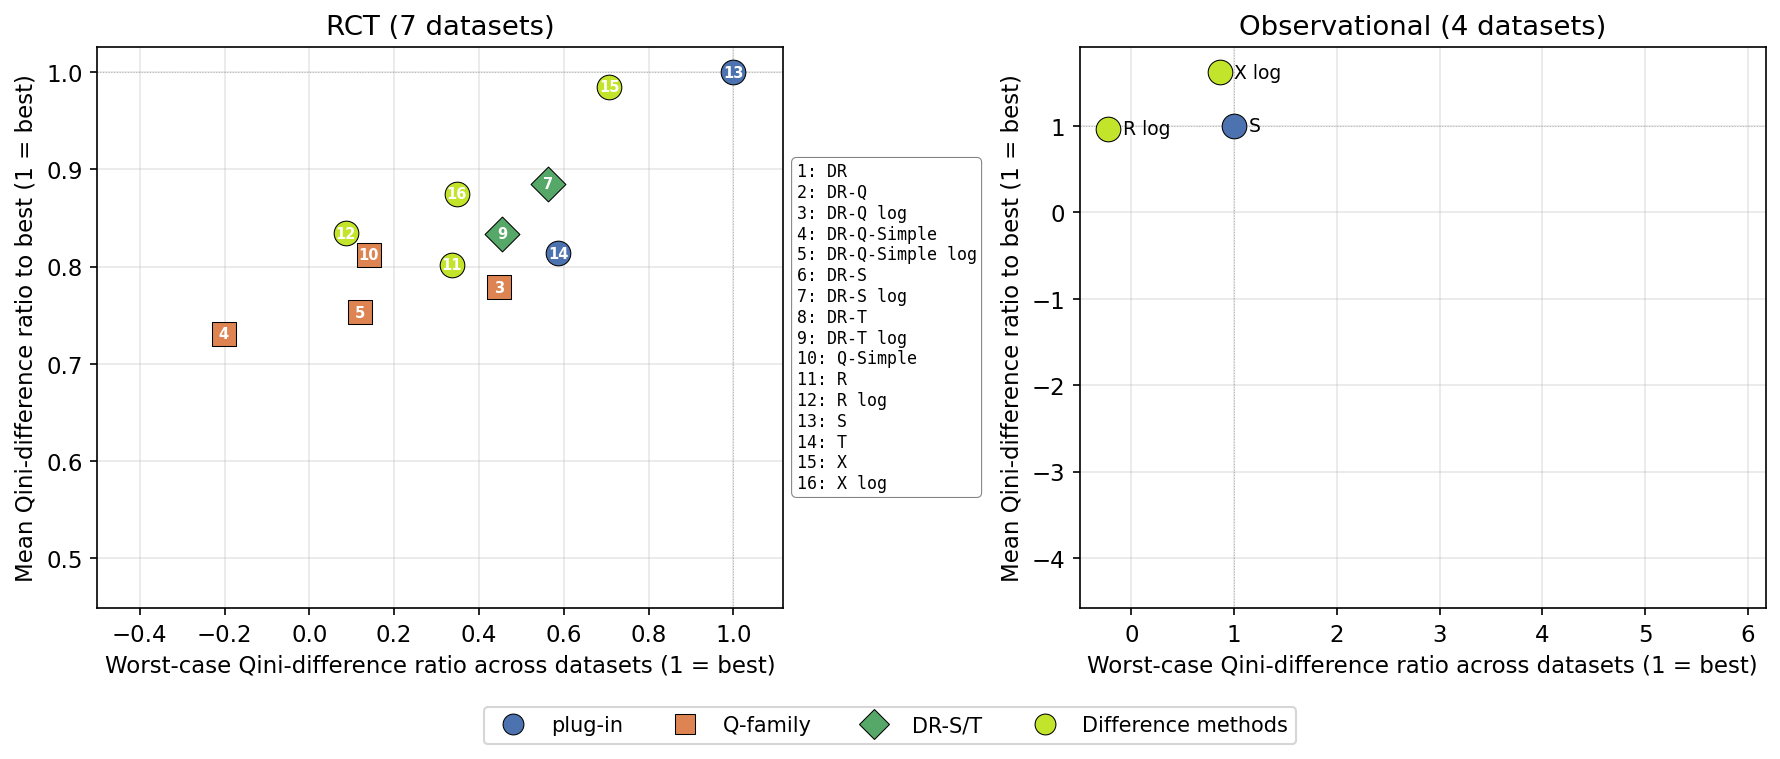

                  mean  worst
label                        
DR               0.565 -0.973
DR-Q             0.513 -0.545
DR-Q log         0.779  0.447
DR-Q-Simple      0.731 -0.203
DR-Q-Simple log  0.753  0.119
DR-S             0.475 -0.819
DR-S log         0.885  0.564
DR-T             0.490 -0.736
DR-T log         0.834  0.454
Q                0.638 -1.341
Q-Simple         0.812  0.140
R                0.802  0.335
R log            0.834  0.086
S                1.000  1.000
T                0.814  0.587
X                0.985  0.708
X log            0.875  0.348

                  mean    worst
label                          
DR              -1.511  -20.994
DR-Q            -4.286  -38.478
DR-Q log        -1.562  -16.415
DR-Q-Simple      0.000      NaN
DR-Q-Simple log  0.000      NaN
DR-S            -3.907  -37.073
DR-S log        -1.873  -22.314
DR-T            -3.836  -37.728
DR-T log        -2.643  -29.916
Q               -1.630  -14.805
Q-Simple         0.000      NaN
R            

In [102]:
# Figure 2 — Qini difference (difference CATE) for RCT vs Observational
fig, summaries = plot_metric_panels(
    df_results,
    metric='qini_difference',
    panels=[
        (f'RCT ({len(RCT_ALL)} datasets)', RCT_ALL),
        (f'Observational ({len(OBS_DATASETS)} datasets)', OBS_DATASETS),
    ],
    plot_learners=PLOT_LEARNERS,
    savepath='fig_qini_difference.png',
)
for s in summaries:
    print(s.round(3))
    print()


### CalError ratio

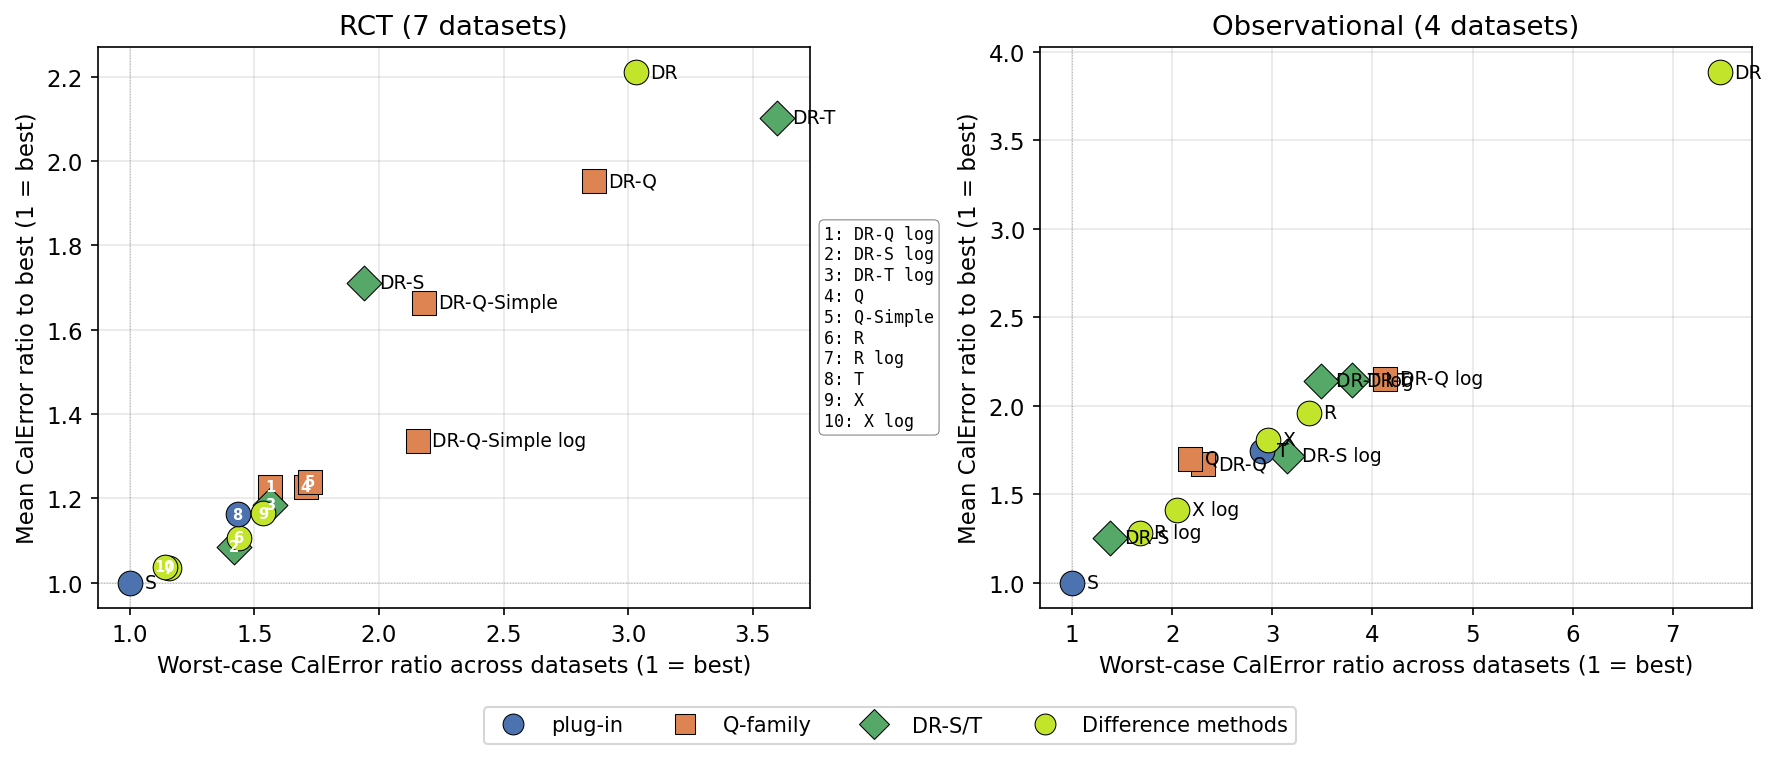

                  mean  worst
label                        
DR               2.211  3.030
DR-Q             1.952  2.862
DR-Q log         1.227  1.563
DR-Q-Simple      1.664  2.180
DR-Q-Simple log  1.336  2.155
DR-S             1.711  1.942
DR-S log         1.085  1.416
DR-T             2.103  3.599
DR-T log         1.185  1.563
Q                1.228  1.705
Q-Simple         1.239  1.721
R                1.106  1.436
R log            1.034  1.159
S                1.000  1.000
T                1.162  1.433
X                1.165  1.535
X log            1.038  1.139

                  mean  worst
label                        
DR               3.885  7.469
DR-Q             1.673  2.310
DR-Q log         2.152  4.126
DR-Q-Simple      0.000    NaN
DR-Q-Simple log  0.000    NaN
DR-S             1.252  1.373
DR-S log         1.717  3.147
DR-T             2.145  3.793
DR-T log         2.140  3.491
Q                1.702  2.178
Q-Simple         0.000    NaN
R                1.961  3.363
R log    

In [103]:
# Figure — CalError ratio for RCT vs Observational
fig, summaries = plot_metric_panels(
    df_results,
    metric='cal_error_ratio',
    panels=[
        (f'RCT ({len(RCT_ALL)} datasets)', RCT_ALL),
        (f'Observational ({len(OBS_DATASETS)} datasets)', OBS_DATASETS),
    ],
    plot_learners=PLOT_LEARNERS,
    savepath='fig_cal_ratio.png',
)
for s in summaries:
    print(s.round(3))
    print()


### CalError difference

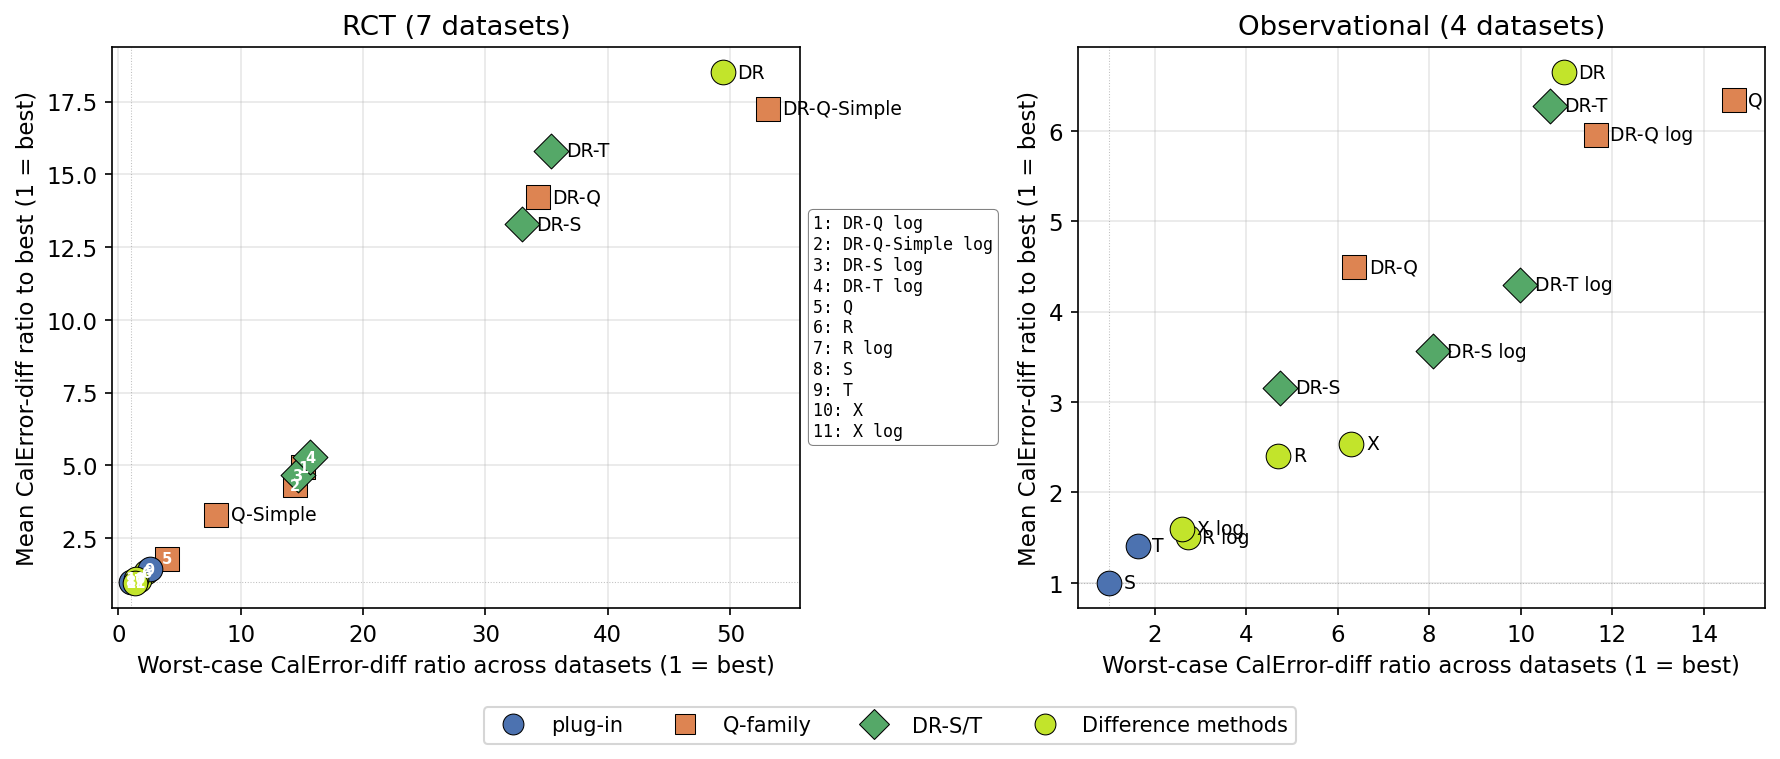

                   mean   worst
label                          
DR               18.510  49.408
DR-Q             14.212  34.291
DR-Q log          4.926  15.102
DR-Q-Simple      17.260  53.066
DR-Q-Simple log   4.315  14.429
DR-S             13.283  32.977
DR-S log          4.653  14.645
DR-T             15.804  35.384
DR-T log          5.277  15.678
Q                 1.775   3.982
Q-Simple          3.287   7.993
R                 1.324   2.274
R log             1.051   1.723
S                 1.000   1.000
T                 1.428   2.569
X                 1.098   1.423
X log             0.965   1.394

                  mean   worst
label                         
DR               6.649  10.950
DR-Q             4.496   6.364
DR-Q log         5.958  11.645
DR-Q-Simple      0.000     NaN
DR-Q-Simple log  0.000     NaN
DR-S             3.157   4.748
DR-S log         3.562   8.080
DR-T             6.275  10.641
DR-T log         4.299   9.987
Q                6.343  14.663
Q-Simple         0.

In [104]:
# Figure — CalError difference for RCT vs Observational
fig, summaries = plot_metric_panels(
    df_results,
    metric='cal_error_difference',
    panels=[
        (f'RCT ({len(RCT_ALL)} datasets)', RCT_ALL),
        (f'Observational ({len(OBS_DATASETS)} datasets)', OBS_DATASETS),
    ],
    plot_learners=PLOT_LEARNERS,
    savepath='fig_cal_difference.png',
)
for s in summaries:
    print(s.round(3))
    print()


### Conversion-rate gradient (RCT)

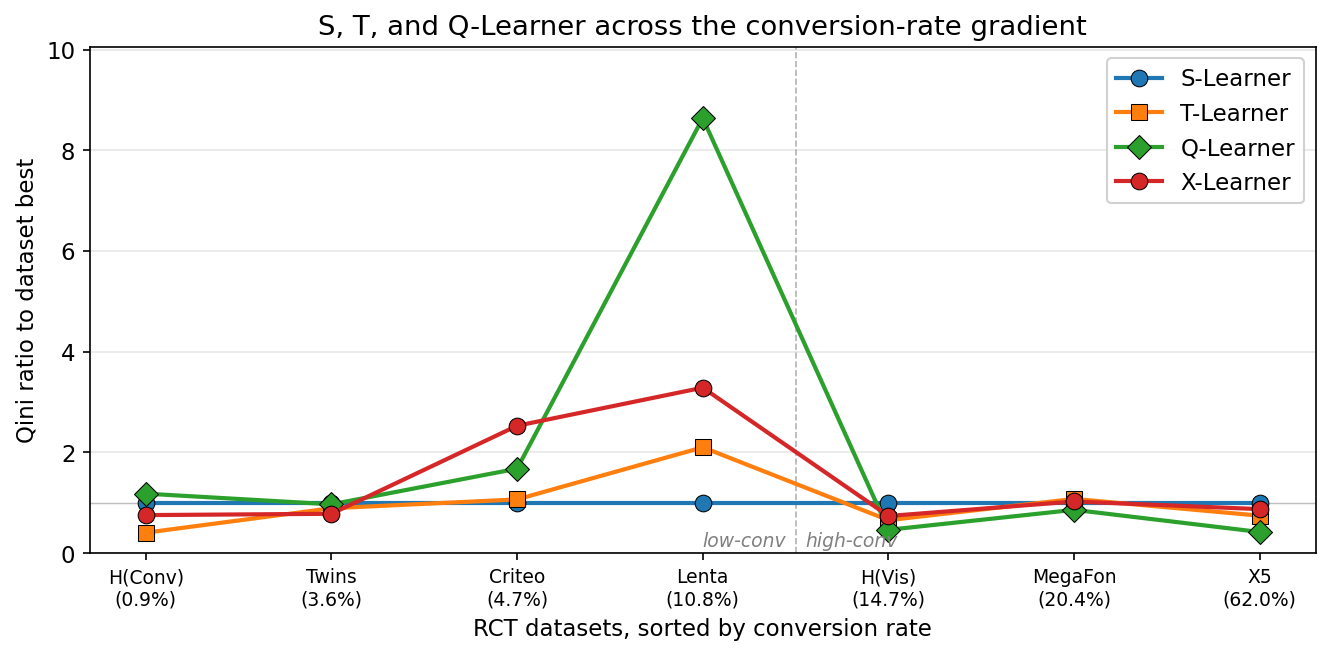

dataset  hillstrom_conversion  twins  criteo  lenta  hillstrom_visit  megafon  \
learner                                                                         
s                       1.000  1.000   1.000  1.000            1.000    1.000   
t                       0.405  0.891   1.066  2.101            0.653    1.075   
q                       1.180  0.968   1.676  8.637            0.462    0.859   

dataset  x5_retail  
learner             
s            1.000  
t            0.743  
q            0.418  


In [105]:
# Figure — S/T/Q across the RCT conversion-rate gradient
ds_order = sorted(RCT_CONV, key=RCT_CONV.get)

sub = df_results[df_results['dataset'].isin(ds_order)]
qini = sub.groupby(['learner', 'dataset'])['qini_ratio'].mean().unstack('dataset')[ds_order]
#max_qini = qini.max(axis=0)
max_qini = qini.loc["s"]

ratio = qini.div(max_qini, axis=1)

LEARNERS = [('s', 'S-Learner', 'tab:blue', 'o'),
            ('t', 'T-Learner', 'tab:orange', 's'),
            ('q', 'Q-Learner', 'tab:green', 'D'),
            ('x', 'X-Learner', 'tab:red', 'o')]

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(ds_order))
for key, label, color, marker in LEARNERS:
    if key not in ratio.index:
        continue
    y = ratio.loc[key].values
    ax.plot(x, y, marker=marker, color=color, label=label,
            linewidth=2, markersize=8, markeredgecolor='black',
            markeredgewidth=0.5, zorder=3)

ax.axhline(1.0, color='gray', linestyle='-', linewidth=0.7, alpha=0.5)

threshold_x = ds_order.index('hillstrom_visit') - 0.5
ax.axvline(threshold_x, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(threshold_x - 0.05, 0.05, 'low-conv', ha='right', va='bottom',
        fontsize=9, color='gray', style='italic')
ax.text(threshold_x + 0.05, 0.05, 'high-conv', ha='left', va='bottom',
        fontsize=9, color='gray', style='italic')

xticklabels = [f'{DS_LABEL[d]}\n({RCT_CONV[d]*100:.1f}%)' for d in ds_order]
ax.set_xticks(x)
ax.set_xticklabels(xticklabels, fontsize=9)
ax.set_ylabel('Qini ratio to dataset best')
ax.set_xlabel('RCT datasets, sorted by conversion rate')
ax.set_ylim(0, 10.05)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper right', framealpha=0.9)
ax.set_title('S, T, and Q-Learner across the conversion-rate gradient')

plt.tight_layout()
plt.savefig('fig_rct_conversion_gradient.png', dpi=150, bbox_inches='tight')
plt.show()
print(ratio.loc[['s', 't', 'q'], ds_order].round(3))


Text(0.5, 1.0, 'S, T, and Q-Learner across the conversion-rate gradient')

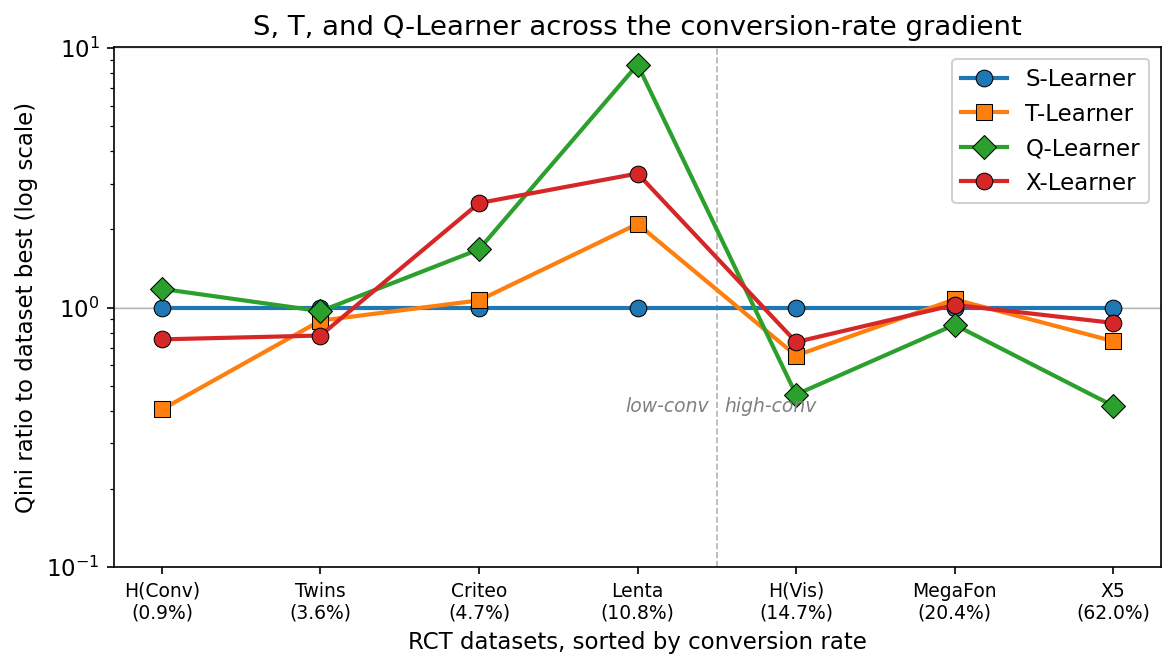

In [106]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(ds_order))
for key, label, color, marker in LEARNERS:
    if key not in ratio.index:
        continue
    y = ratio.loc[key].values
    ax.plot(x, y, marker=marker, color=color, label=label,
            linewidth=2, markersize=8, markeredgecolor='black',
            markeredgewidth=0.5, zorder=3)

ax.set_yscale('log')

ax.axhline(1.0, color='gray', linestyle='-', linewidth=0.7, alpha=0.5)

threshold_x = ds_order.index('hillstrom_visit') - 0.5
ax.axvline(threshold_x, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(threshold_x - 0.05, ax.get_ylim()[0] * 1.1, 'low-conv', ha='right', va='bottom',
        fontsize=9, color='gray', style='italic')
ax.text(threshold_x + 0.05, ax.get_ylim()[0] * 1.1, 'high-conv', ha='left', va='bottom',
        fontsize=9, color='gray', style='italic')

xticklabels = [f'{DS_LABEL[d]}\n({RCT_CONV[d]*100:.1f}%)' for d in ds_order]
ax.set_xticks(x)
ax.set_xticklabels(xticklabels, fontsize=9)
ax.set_ylabel('Qini ratio to dataset best (log scale)')
ax.set_xlabel('RCT datasets, sorted by conversion rate')
ax.set_ylim(bottom=0.1)          # log scale must not include 0
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper right', framealpha=0.9)
ax.set_title('S, T, and Q-Learner across the conversion-rate gradient')


### Qini split by conversion-rate regime

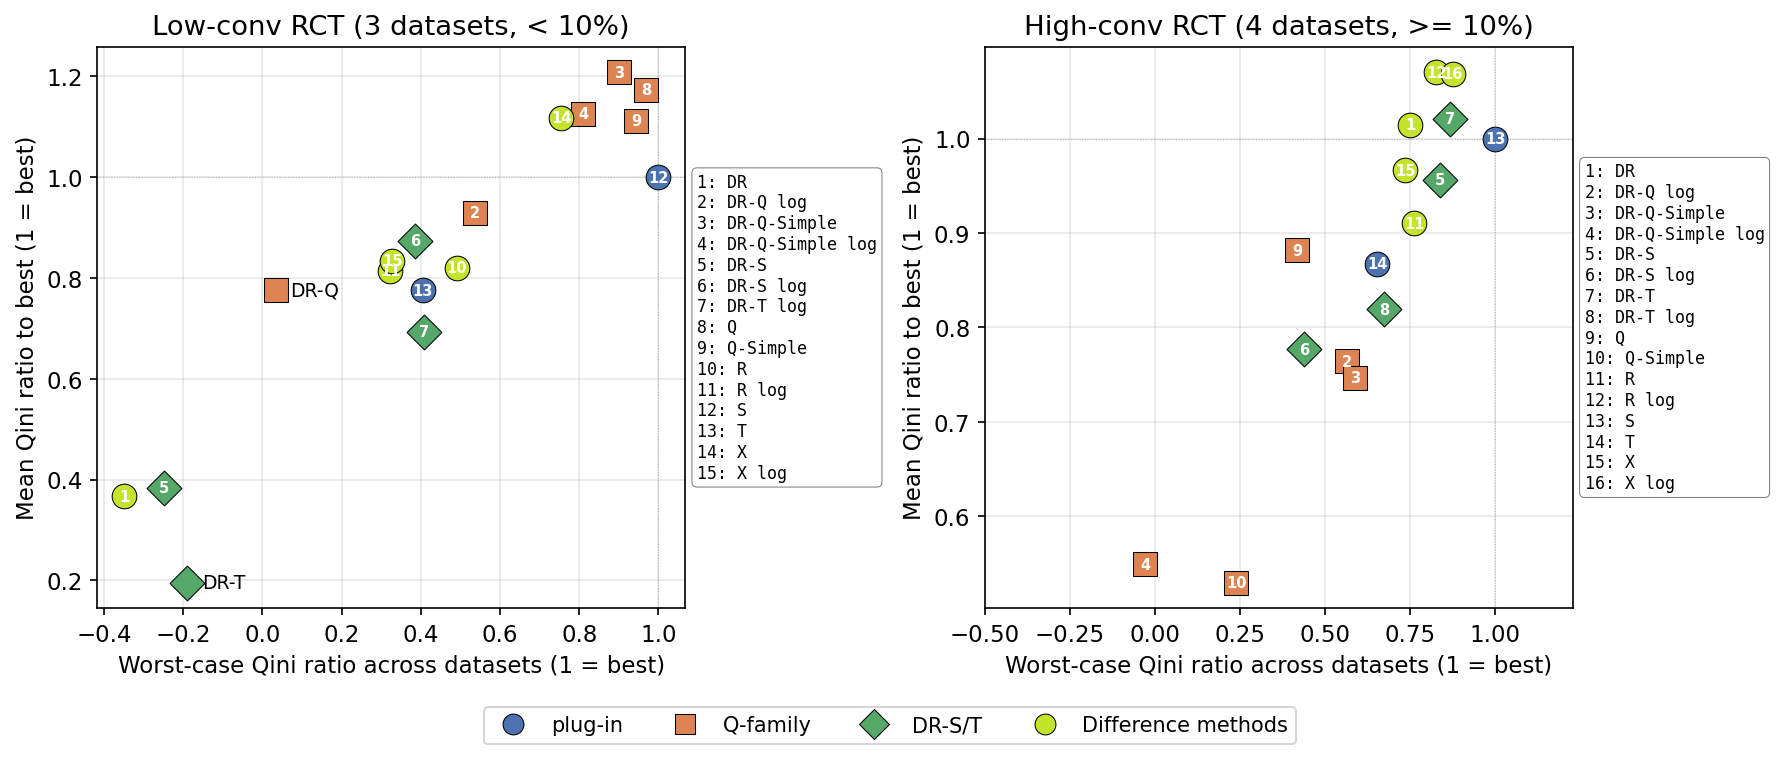

                  mean  worst
label                        
DR               0.367 -0.349
DR-Q             0.776  0.033
DR-Q log         0.930  0.537
DR-Q-Simple      1.208  0.901
DR-Q-Simple log  1.126  0.810
DR-S             0.384 -0.248
DR-S log         0.873  0.386
DR-T             0.195 -0.189
DR-T log         0.693  0.409
Q                1.174  0.968
Q-Simple         1.111  0.943
R                0.820  0.491
R log            0.814  0.323
S                1.000  1.000
T                0.775  0.405
X                1.118  0.754
X log            0.834  0.328

                  mean  worst
label                        
DR               1.014  0.750
DR-Q             0.666 -3.571
DR-Q log         0.764  0.565
DR-Q-Simple      0.746  0.589
DR-Q-Simple log  0.549 -0.029
DR-S             0.957  0.839
DR-S log         0.777  0.438
DR-T             1.021  0.869
DR-T log         0.819  0.673
Q                0.881  0.418
Q-Simple         0.529  0.239
R                0.910  0.762
R log    

In [107]:
# Figure — Qini ratio split by RCT conversion-rate regime
fig, summaries = plot_metric_panels(
    df_results,
    metric='qini_ratio',
    panels=[
        (f'Low-conv RCT ({len(RCT_LOW_CONV)} datasets, < 10%)',  RCT_LOW_CONV),
        (f'High-conv RCT ({len(RCT_HIGH_CONV)} datasets, >= 10%)', RCT_HIGH_CONV),
    ],
    plot_learners=PLOT_LEARNERS,
    savepath='fig_qini_ratio_by_regime.png',
)
for s in summaries:
    print(s.round(3))
    print()


## LaTeX Tables

In [108]:
# LaTeX tables: per-dataset Qini and CalError, ratio and difference scales

QINI_RATIO_CAPTION_TPL = (
    'Qini coefficient (ratio CATE) on {kind} datasets (mean over 100 seeds; '
    r'SE in parentheses). Best per column in \textbf{bold}. $R_{\min}$ is the '
    r"worst-case per-dataset ratio $Q_{l,d}/\max_{l'} Q_{l',d}$ across datasets. "
    'Bottom row: mean across all learners per dataset.'
)
QINI_DIFF_CAPTION_TPL = (
    'Qini coefficient (difference CATE, cumulative-gain formulation) on {kind} datasets '
    '(mean over 100 seeds; SE in parentheses). '
    r'Best per column in \textbf{bold}. $R_{\min}$ is the worst-case per-dataset ratio.'
)
CAL_RATIO_CAPTION_TPL = (
    'Multiplicative calibration error (ratio CATE) on {kind} datasets '
    '(mean over 100 seeds; SE in parentheses). '
    r'Best per column in \textbf{bold}. $R_{\max}$ is the worst-case per-dataset ratio.'
)
CAL_DIFF_CAPTION_TPL = (
    'Calibration error (difference CATE) on {kind} datasets '
    '(mean over 100 seeds; SE in parentheses). '
    r'Best per column in \textbf{bold}. $R_{\max}$ is the worst-case per-dataset ratio.'
)


def emit(metric_key, datasets, kind, label, caption_tpl):
    print(make_metric_table(
        df_results, metric=metric_key, datasets=datasets,
        caption=caption_tpl.replace('{kind}', kind), label=label,
        plot_learners=PLOT_LEARNERS,
    ))
    print('\n\n')


# Qini ratio
emit('qini_ratio', RCT_ALL,       'RCT',            'tab:qini-ratio-rct',  QINI_RATIO_CAPTION_TPL)
emit('qini_ratio', OBS_DATASETS,  'observational',  'tab:qini-ratio-obs',  QINI_RATIO_CAPTION_TPL)

# Qini difference
emit('qini_difference', RCT_ALL,      'RCT',           'tab:qini-diff-rct', QINI_DIFF_CAPTION_TPL)
emit('qini_difference', OBS_DATASETS, 'observational', 'tab:qini-diff-obs', QINI_DIFF_CAPTION_TPL)

# CalError ratio
emit('cal_error_ratio', RCT_ALL,      'RCT',           'tab:cal-ratio-rct', CAL_RATIO_CAPTION_TPL)
emit('cal_error_ratio', OBS_DATASETS, 'observational', 'tab:cal-ratio-obs', CAL_RATIO_CAPTION_TPL)

# CalError difference
emit('cal_error_difference', RCT_ALL,      'RCT',           'tab:cal-diff-rct', CAL_DIFF_CAPTION_TPL)
emit('cal_error_difference', OBS_DATASETS, 'observational', 'tab:cal-diff-obs', CAL_DIFF_CAPTION_TPL)


\begin{table}[H]
\centering
\footnotesize
\caption{Qini coefficient (ratio CATE) on RCT datasets (mean over 100 seeds; SE in parentheses). Best per column in \textbf{bold}. $R_{\min}$ is the worst-case per-dataset ratio $Q_{l,d}/\max_{l'} Q_{l',d}$ across datasets. Bottom row: mean across all learners per dataset.}
\label{tab:qini-ratio-rct}
\setlength{\tabcolsep}{3pt}
\begin{tabular}{l | rrrrrrr | r r}
\hline
Learner & H(Vis) & H(Conv) & Criteo & MegaFon & X5 & Lenta & Twins & $\bar{Q}$ & $R_{\min}$ \\
\hline
S
 & \textbf{0.437} & 0.419 & 0.337 & 1.436 & 0.073 & 0.011 & 0.089 & 0.400 & 0.116 \\
 & \scriptsize(0.025) & \scriptsize(0.099) & \scriptsize(0.003) & \scriptsize(0.007) & \scriptsize(0.002) & \scriptsize(0.004) & \scriptsize(0.009) & & \\[2pt]
T
 & 0.285 & 0.170 & 0.359 & \textbf{1.544} & 0.055 & 0.023 & 0.079 & 0.359 & 0.243 \\
 & \scriptsize(0.018) & \scriptsize(0.062) & \scriptsize(0.003) & \scriptsize(0.007) & \scriptsize(0.002) & \scriptsize(0.002) & \scriptsize(0.011) & 